In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df = pd.read_csv("Online_Retail_Cleaned.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 532132
Columns: 8


In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532132 entries, 0 to 532131
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    532132 non-null  object 
 1   StockCode    532132 non-null  object 
 2   Description  532132 non-null  object 
 3   Quantity     532132 non-null  int64  
 4   InvoiceDate  532132 non-null  object 
 5   UnitPrice    532132 non-null  float64
 6   CustomerID   399932 non-null  float64
 7   Country      532132 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.5+ MB


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,132200
Country,0


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,532132.000000,532132.000000,399932.000000
mean,10.016107,3.346930,15288.334672
std,217.681087,6.960386,1710.506855
min,-80995.000000,0.000000,12346.000000
25%,1.000000,1.250000,13959.000000
50%,3.000000,2.080000,15150.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,1867.860000,18287.000000


In [ ]:
print("Unique Invoices:", df["InvoiceNo"].nunique())
print("Unique Products:", df["StockCode"].nunique())
print("Unique Countries:", df["Country"].nunique())
print("Unique Customers:", df["CustomerID"].nunique())

Unique Invoices: 23500
Unique Products: 3934
Unique Countries: 38
Unique Customers: 4363


In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("InvoiceDate converted successfully!")
print(df["InvoiceDate"].dtype)

InvoiceDate converted successfully!
datetime64[ns]


In [11]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [12]:
df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

df[["InvoiceDate", "Year", "Month", "MonthName", "DayOfWeek", "Hour"]].head()

,InvoiceDate,Year,Month,MonthName,DayOfWeek,Hour
0,2010-12-01 08:26:00,2010,12,December,Wednesday,8
1,2010-12-01 08:26:00,2010,12,December,Wednesday,8
2,2010-12-01 08:26:00,2010,12,December,Wednesday,8
3,2010-12-01 08:26:00,2010,12,December,Wednesday,8
4,2010-12-01 08:26:00,2010,12,December,Wednesday,8


In [13]:
print("Negative Quantity Records:", (df["Quantity"] < 0).sum())
print("Zero Quantity Records:", (df["Quantity"] == 0).sum())
print("Positive Quantity Records:", (df["Quantity"] > 0).sum())

Negative Quantity Records: 8848
Zero Quantity Records: 0
Positive Quantity Records: 523284


In [14]:
negative_qty = df[df["Quantity"] < 0]

print("Negative quantity records:", len(negative_qty))
print("\nSample negative quantity records:")
negative_qty[["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]].head(10)

Negative quantity records: 8848

Sample negative quantity records:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
140,C536379,D,Discount,-1,27.50
153,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65
234,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65
235,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29
236,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29
237,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29
238,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45
239,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65
240,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65
913,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25


In [15]:
negative_qty = df[df["Quantity"] < 0].copy()

print("Negative quantity records:", len(negative_qty))
print("Negative quantity invoices:", negative_qty["InvoiceNo"].nunique())
print("Negative revenue:", negative_qty["Revenue"].sum())

print("\nCancellation invoices:")
print(negative_qty["InvoiceNo"].astype(str).str.startswith("C").value_counts())

Negative quantity records: 8848
Negative quantity invoices: 3545
Negative revenue: -500039.15

Cancellation invoices:
InvoiceNo
True    8848
Name: count, dtype: int64


In [16]:
print("Total Revenue:", df["Revenue"].sum())
print("Positive Sales Revenue:", df.loc[df["Quantity"] > 0, "Revenue"].sum())
print("Return/Cancellation Revenue:", df.loc[df["Quantity"] < 0, "Revenue"].sum())

print("\nRevenue Statistics:")
print(df["Revenue"].describe())

Total Revenue: 9755145.034
Positive Sales Revenue: 10255184.184
Return/Cancellation Revenue: -500039.15

Revenue Statistics:
count    532132.000000
mean         18.332190
std         369.474787
min     -168469.600000
25%           3.750000
50%           9.870000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64


In [17]:
monthly_revenue = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["InvoiceDate"] = monthly_revenue["InvoiceDate"].astype(str)

print(monthly_revenue)

   InvoiceDate      Revenue
0      2010-12   756960.860
1      2011-01   578006.290
2      2011-02   497692.220
3      2011-03   679362.880
4      2011-04   480123.291
5      2011-05   730415.210
6      2011-06   723019.750
7      2011-07   677209.481
8      2011-08   699193.830
9      2011-09  1010464.172
10     2011-10  1059368.070
11     2011-11  1423835.210
12     2011-12   439493.770


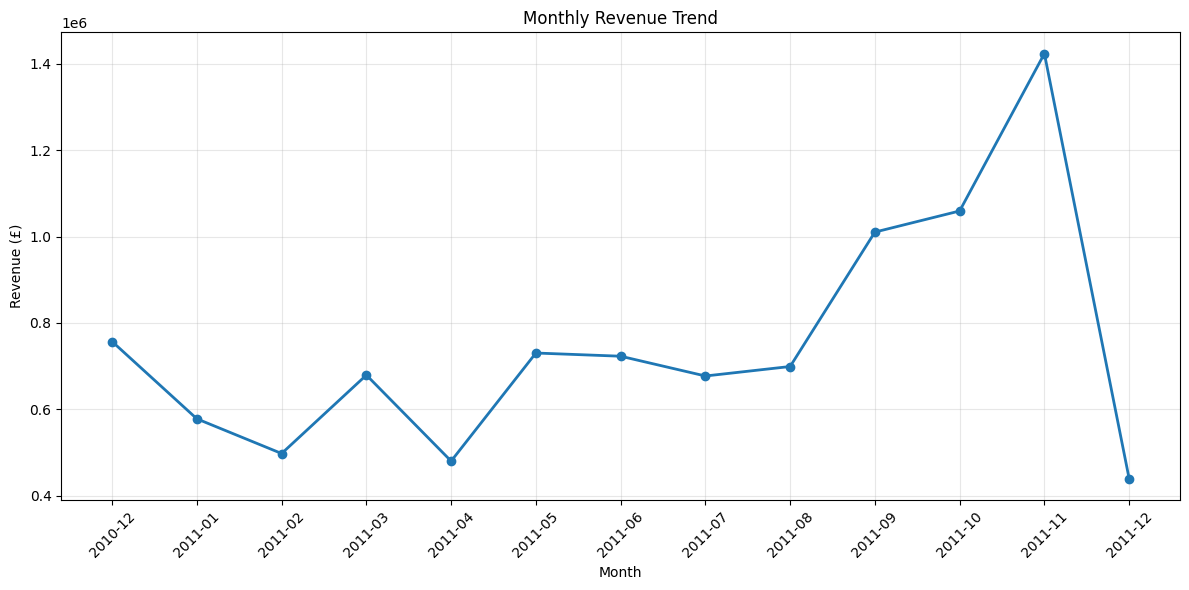

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue["InvoiceDate"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [19]:
top_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(top_products)

                          Description    Revenue
0            REGENCY CAKESTAND 3 TIER  164459.49
1  WHITE HANGING HEART T-LIGHT HOLDER   99612.42
2                       PARTY BUNTING   98243.88
3             JUMBO BAG RED RETROSPOT   92175.79
4                  RABBIT NIGHT LIGHT   66661.63
5     PAPER CHAIN KIT 50'S CHRISTMAS    63715.24
6       ASSORTED COLOUR BIRD ORNAMENT   58792.42
7                       CHILLI LIGHTS   53746.66
8                      SPOTTY BUNTING   42030.67
9             JUMBO BAG PINK POLKADOT   41584.43


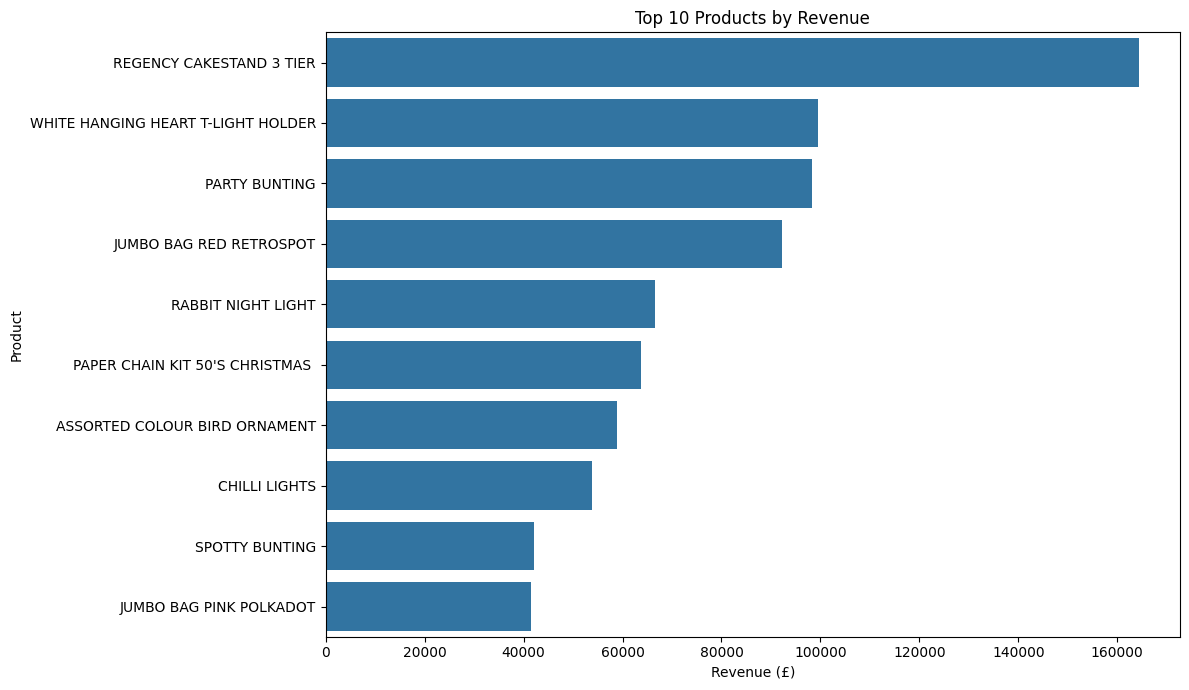

In [20]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [21]:
country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(country_revenue)

          Country      Revenue
0  United Kingdom  8260373.474
1     Netherlands   283273.140
2            EIRE   264120.510
3         Germany   200619.660
4          France   182262.600
5       Australia   136922.500
6     Switzerland    52483.050
7           Spain    51746.650
8         Belgium    36662.960
9           Japan    35419.790


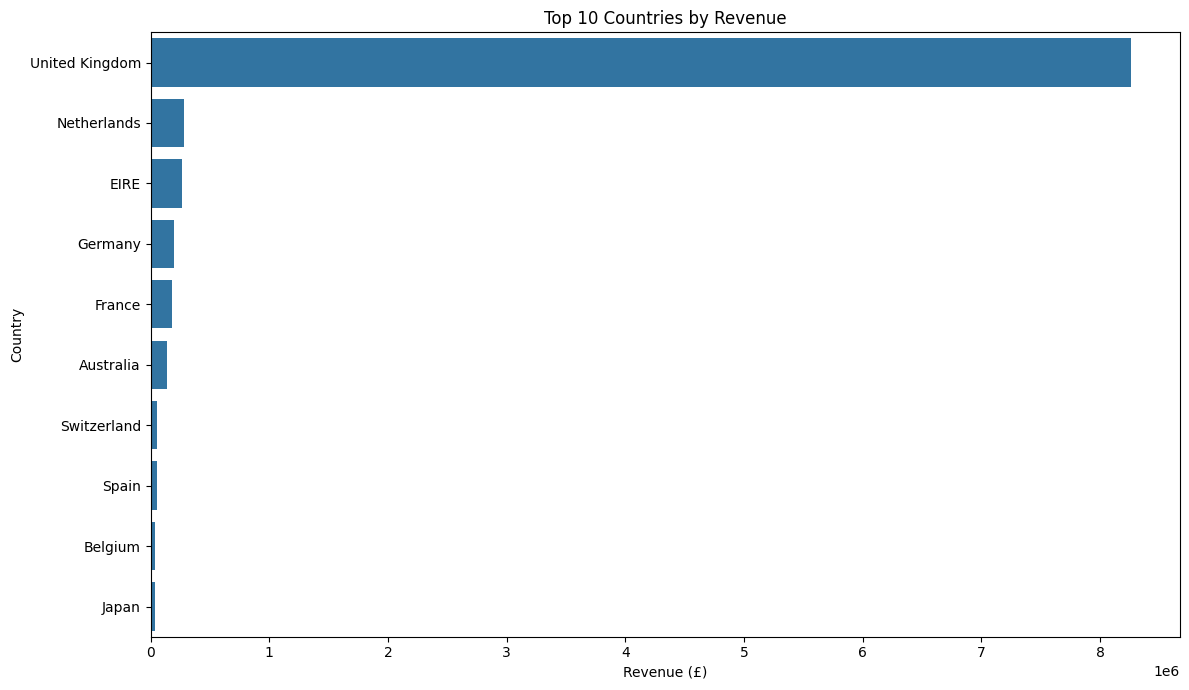

In [22]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_revenue,
    x="Revenue",
    y="Country"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [23]:
country_orders = (
    df.groupby("Country")["InvoiceNo"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(country_orders)

          Country  InvoiceNo
0  United Kingdom      21228
1         Germany        578
2          France        442
3            EIRE        350
4         Belgium        117
5           Spain        100
6     Netherlands         98
7     Switzerland         68
8       Australia         67
9        Portugal         56


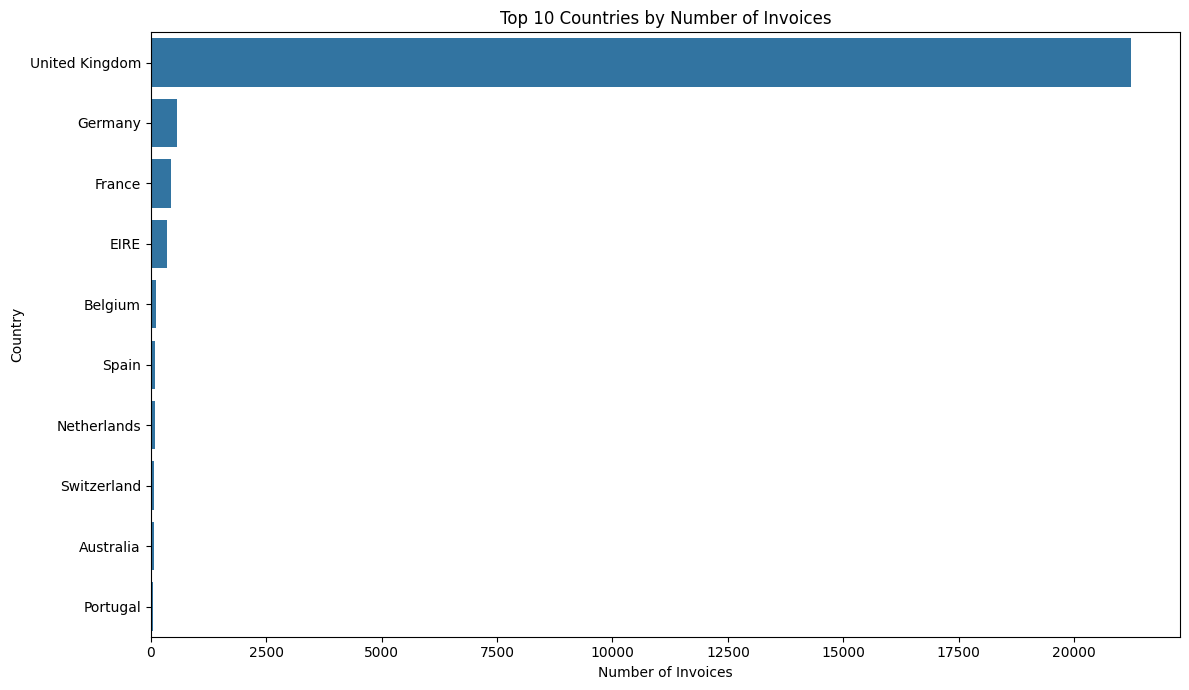

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=country_orders,
    x="InvoiceNo",
    y="Country"
)

plt.title("Top 10 Countries by Number of Invoices")
plt.xlabel("Number of Invoices")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

In [25]:
day_revenue = (
    df.groupby("DayOfWeek")["Revenue"]
      .sum()
      .reindex([
          "Monday", "Tuesday", "Wednesday",
          "Thursday", "Friday", "Saturday", "Sunday"
      ])
      .reset_index()
)

print(day_revenue)

   DayOfWeek      Revenue
0     Monday  1613777.971
1    Tuesday  1966593.231
2  Wednesday  1736565.110
3   Thursday  2078846.600
4     Friday  1568526.031
5   Saturday          NaN
6     Sunday   790836.091


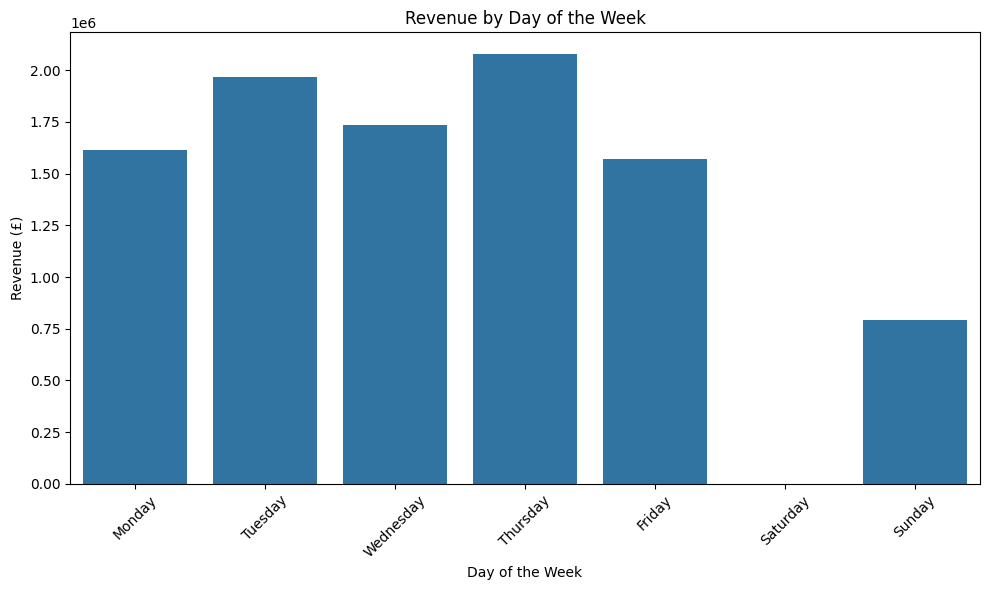

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=day_revenue,
    x="DayOfWeek",
    y="Revenue"
)

plt.title("Revenue by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
hourly_revenue = (
    df.groupby("Hour")["Revenue"]
      .sum()
      .reset_index()
)

print(hourly_revenue)

    Hour      Revenue
0      6     -497.350
1      7    30469.320
2      8   277890.020
3      9   772010.911
4     10  1296888.711
5     11  1161492.300
6     12  1392110.500
7     13  1178246.990
8     14  1090118.201
9     15  1250226.710
10    16   689590.550
11    17   419463.001
12    18   135023.900
13    19    46188.580
14    20    15922.690


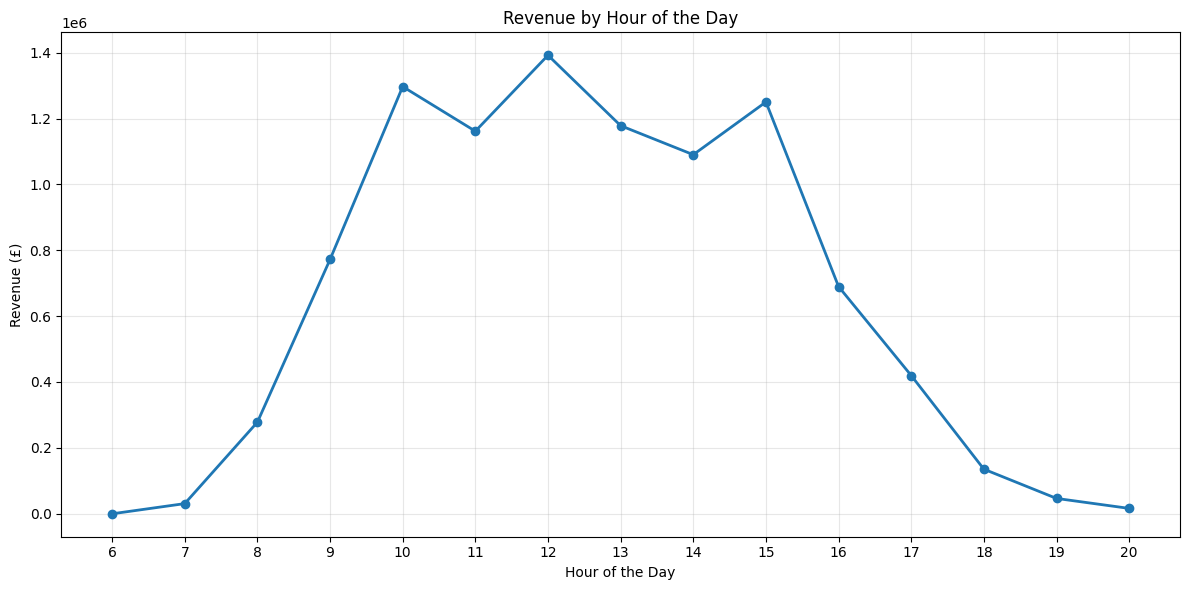

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_revenue["Hour"],
    hourly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Revenue by Hour of the Day")
plt.xlabel("Hour of the Day")
plt.ylabel("Revenue (£)")
plt.xticks(hourly_revenue["Hour"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

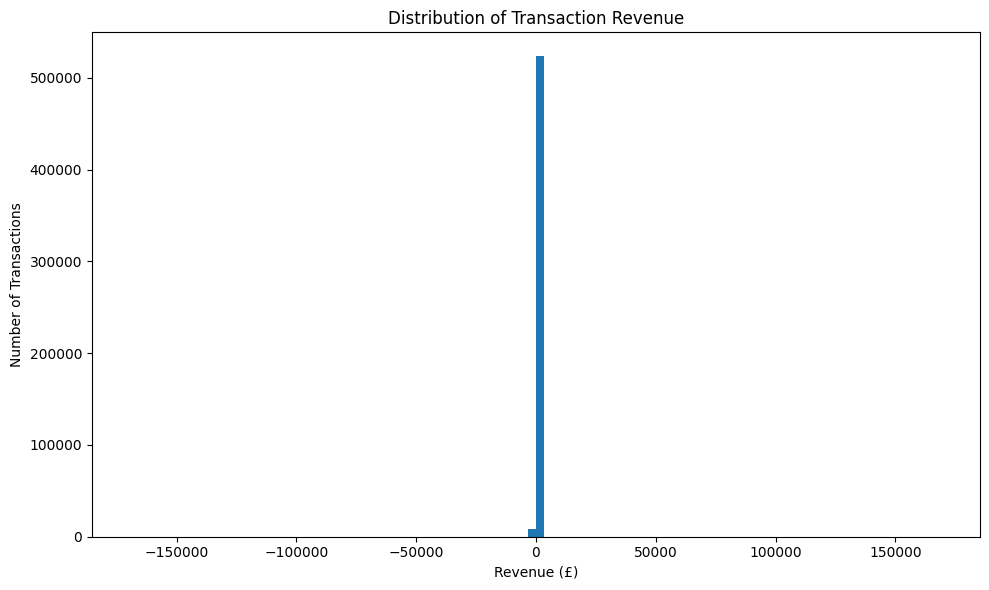

In [29]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Revenue"],
    bins=100
)

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

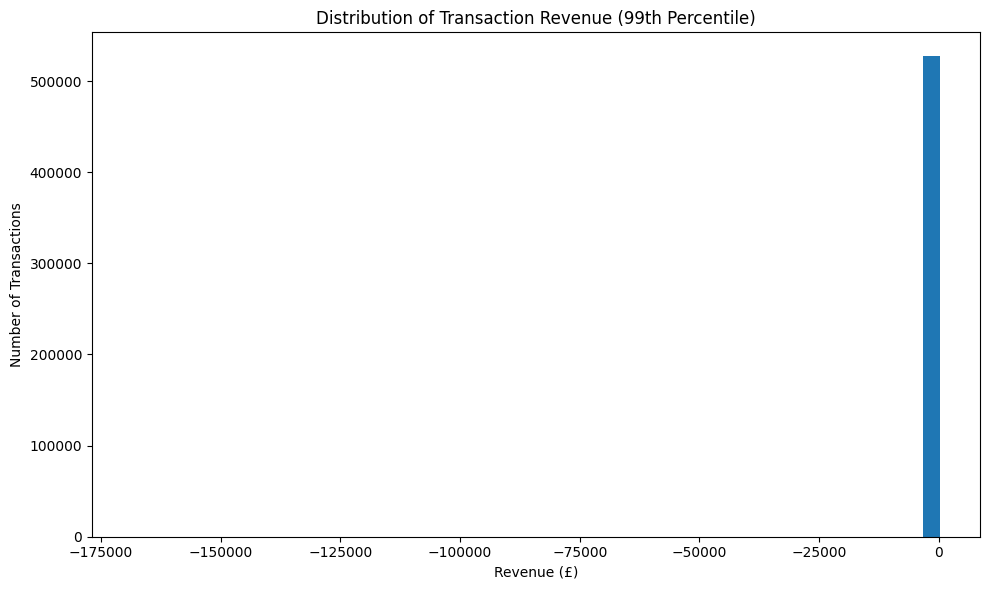

In [30]:
revenue_99 = df["Revenue"].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    df.loc[df["Revenue"] <= revenue_99, "Revenue"],
    bins=50
)

plt.title("Distribution of Transaction Revenue (99th Percentile)")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

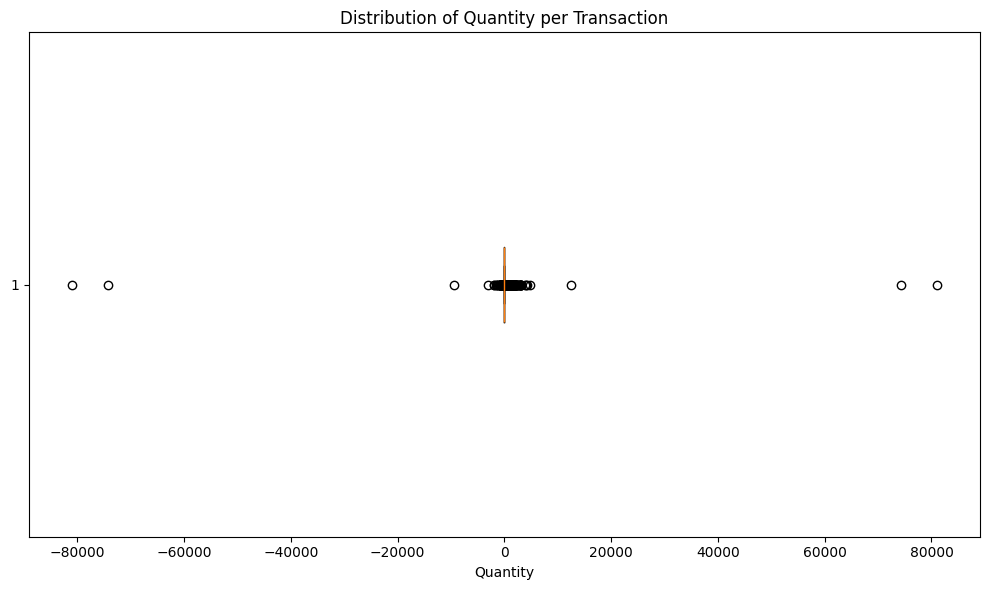

In [31]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["Quantity"],
    vert=False
)

plt.title("Distribution of Quantity per Transaction")
plt.xlabel("Quantity")
plt.tight_layout()
plt.show()

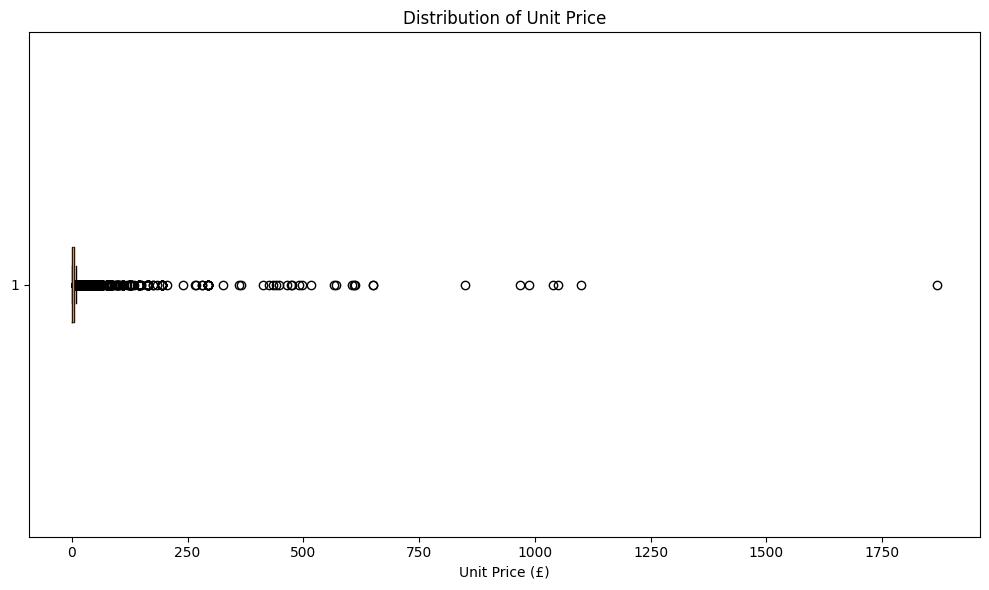

In [32]:
plt.figure(figsize=(10, 6))

plt.boxplot(
    df["UnitPrice"],
    vert=False
)

plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price (£)")
plt.tight_layout()
plt.show()

In [33]:
correlation = df[["Quantity", "UnitPrice", "Revenue"]].corr()

print(correlation)

           Quantity  UnitPrice   Revenue
Quantity   1.000000  -0.010026  0.927245
UnitPrice -0.010026   1.000000  0.016339
Revenue    0.927245   0.016339  1.000000


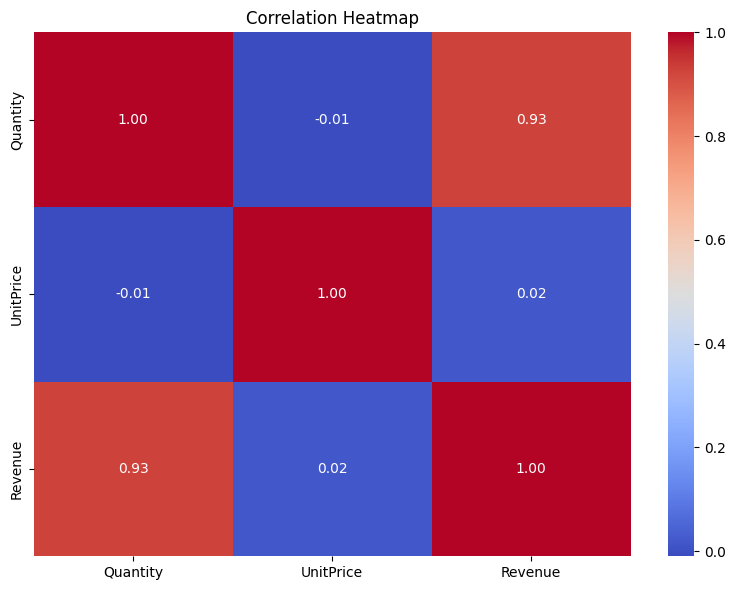

In [34]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [35]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

print(customer_revenue)

   CustomerID    Revenue
0     14646.0  278571.62
1     18102.0  259657.30
2     17450.0  189490.73
3     14911.0  132458.73
4     12415.0  123638.18
5     14156.0  114335.77
6     17511.0   88138.20
7     16684.0   65892.08
8     13694.0   62714.54
9     16029.0   60177.89


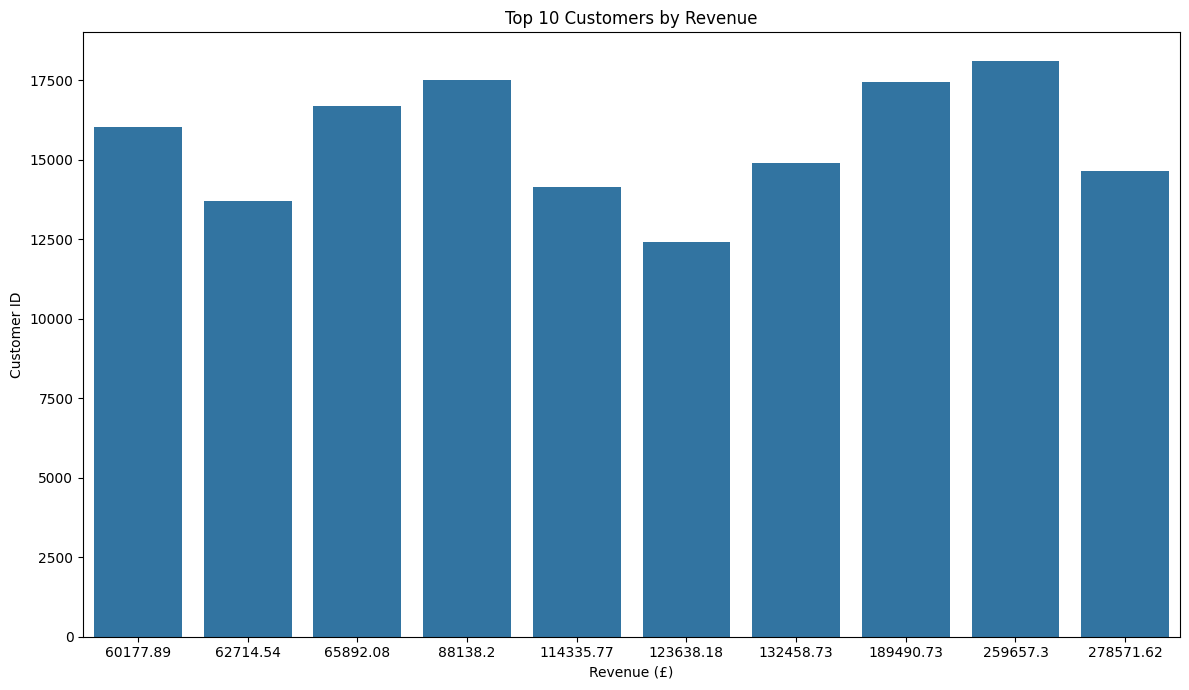

In [36]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=customer_revenue,
    x="Revenue",
    y="CustomerID"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Customer ID")
plt.tight_layout()
plt.show()

In [37]:
cancellation_monthly = (
    df[df["Quantity"] < 0]
    .groupby(df["InvoiceDate"].dt.to_period("M"))
    .size()
    .reset_index(name="CancellationCount")
)

cancellation_monthly["InvoiceDate"] = cancellation_monthly["InvoiceDate"].astype(str)

print(cancellation_monthly)

   InvoiceDate  CancellationCount
0      2010-12                701
1      2011-01                681
2      2011-02                449
3      2011-03                648
4      2011-04                534
5      2011-05                578
6      2011-06                684
7      2011-07                647
8      2011-08                639
9      2011-09                769
10     2011-10               1135
11     2011-11               1034
12     2011-12                349


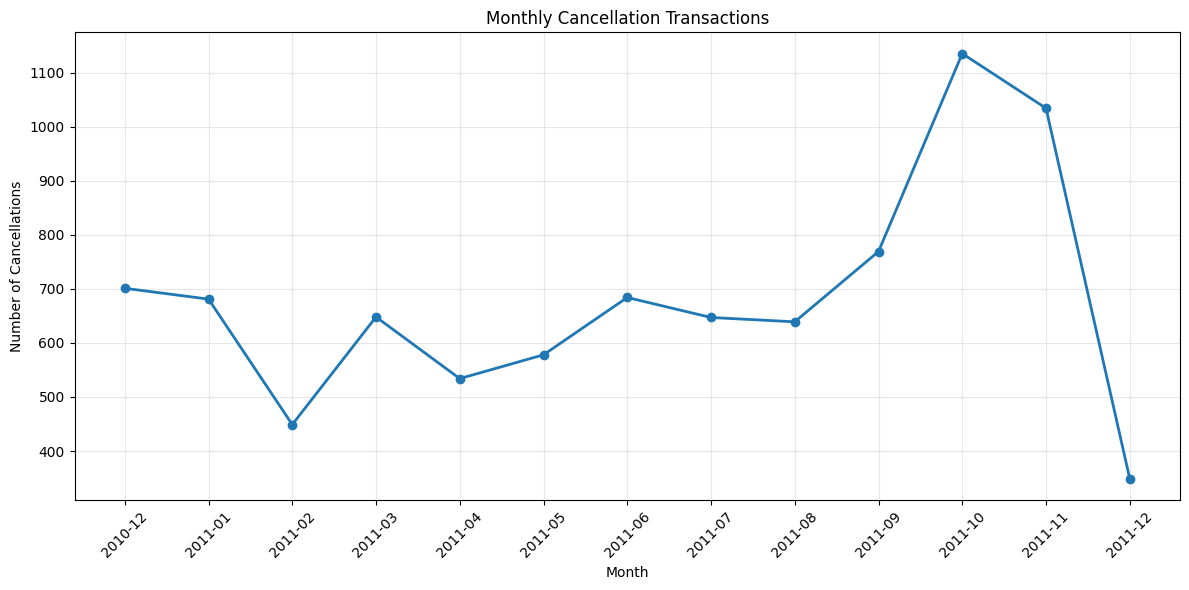

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    cancellation_monthly["InvoiceDate"],
    cancellation_monthly["CancellationCount"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Cancellation Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Cancellations")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
cancellation_revenue_monthly = (
    df[df["Quantity"] < 0]
    .groupby(df["InvoiceDate"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

cancellation_revenue_monthly["InvoiceDate"] = (
    cancellation_revenue_monthly["InvoiceDate"].astype(str)
)

print(cancellation_revenue_monthly)

   InvoiceDate    Revenue
0      2010-12  -19369.09
1      2011-01  -92648.17
2      2011-02  -10389.32
3      2011-03  -11228.96
4      2011-04  -35791.37
5      2011-05  -10072.12
6      2011-06  -15214.24
7      2011-07  -11593.19
8      2011-08  -25514.33
9      2011-09  -18811.21
10     2011-10  -44725.90
11     2011-11  -29460.77
12     2011-12 -175220.48


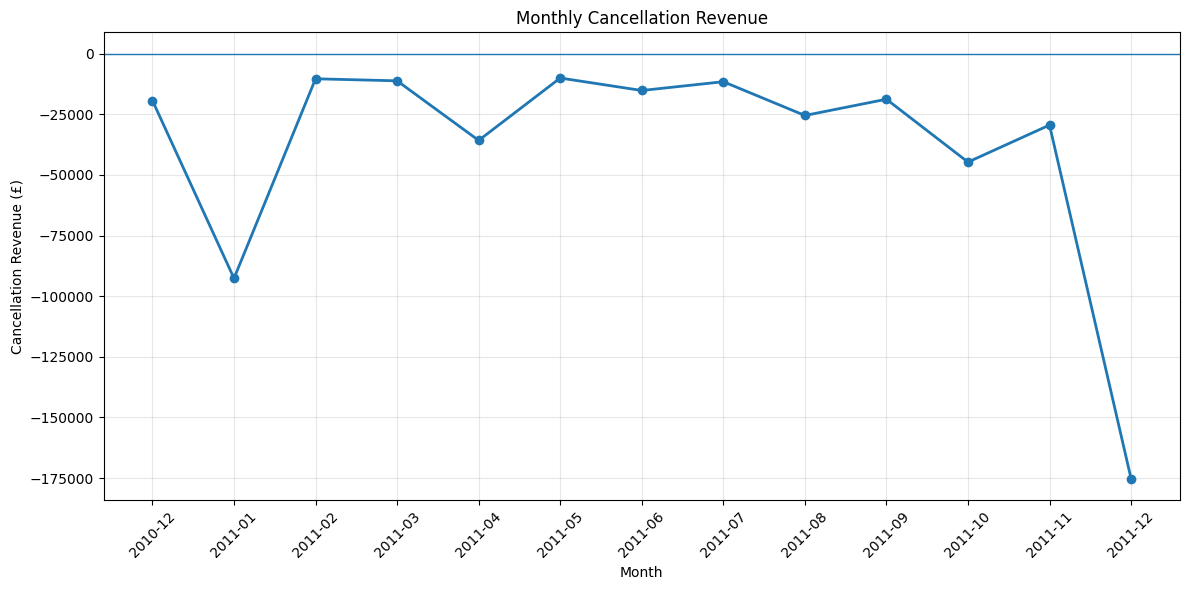

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    cancellation_revenue_monthly["InvoiceDate"],
    cancellation_revenue_monthly["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Cancellation Revenue")
plt.xlabel("Month")
plt.ylabel("Cancellation Revenue (£)")
plt.xticks(rotation=45)
plt.axhline(0, linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()